# Waze User Churn Prediction
### Random Forest and XGBoost Classification Project

## Project Overview

This project explores how machine learning can be used to predict user churn using behavioral usage data from Waze.

I built and compared two tree-based classification models, **Random Forest** and **XGBoost**, to identify patterns associated with churn and evaluate which model performs better for this business problem.

This notebook was originally developed as part of an advanced data analytics training project and has been adapted here into a portfolio-ready machine learning case study.

## Business Problem

User churn is an important business challenge because losing active users can reduce engagement, retention, and long-term product value.

The goal of this project is to predict whether a user is likely to churn based on activity patterns, session behavior, and driving-related features. In addition to prediction, this analysis helps identify which behaviors are most associated with churn.

## Objective

The objective of this project is to:

- build classification models that predict user churn
- compare Random Forest and XGBoost performance
- prioritize recall in model selection to better identify users at risk of churning
- interpret feature importance to understand likely churn drivers

## Project Workflow

This notebook follows a standard machine learning workflow:

1. Load and inspect the dataset
2. Engineer features from behavioral variables
3. Prepare the target and model features
4. Split the data into training, validation, and test sets
5. Train and tune Random Forest and XGBoost models
6. Compare validation performance
7. Select a champion model
8. Evaluate final performance on the test set
9. Review confusion matrix and feature importance

## Ethical Considerations

This model could be useful for targeting retention efforts, but model errors still matter.

A **false negative** means the model predicts a user will stay when they are actually likely to churn. In that case, the business may miss the chance to intervene and retain that user.

A **false positive** means the model predicts a user will churn when they would have stayed anyway. That may lead to unnecessary retention efforts or incentives, but this is generally less costly than missing a real churn risk.

Because the cost of missing likely churners is more important here, **recall** is the most appropriate metric for model selection.

This model should be used as a decision-support tool rather than a fully automated decision system.

## 1. Imports and Data Loading

In [2]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt

# Display all columns in Jupyter
pd.set_option('display.max_columns', None)

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier, plot_importance

# Save fitted models if needed
import pickle

In [3]:
# Load dataset
df0 = pd.read_csv("waze_dataset.csv")

In [4]:
# Inspect first five rows
df0.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [5]:
# Inspect basic info
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  str    
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  str    
dtypes: float64(3), int64(8), str(2)
memory usage: 1.5 MB


## 2. Feature Engineering

To improve predictive power, I created several behavioral features from the raw dataset. These engineered variables are intended to better capture user intensity, driving frequency, session patterns, and navigation preferences.

In [6]:
# Create working copy
df = df0.copy()

In [7]:
# Create km_per_driving_day
df["km_per_driving_day"] = df["driven_km_drives"] / df["driving_days"]
df["km_per_driving_day"] = df["km_per_driving_day"].replace([np.inf, -np.inf], 0)

df["km_per_driving_day"].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

In [8]:
# Create percent_sessions_in_last_month
df["percent_sessions_in_last_month"] = df["sessions"] / df["total_sessions"]

df["percent_sessions_in_last_month"].describe()

count    14999.000000
mean         0.449255
std          0.286919
min          0.000000
25%          0.196221
50%          0.423097
75%          0.687216
max          1.530637
Name: percent_sessions_in_last_month, dtype: float64

In [9]:
# Create professional_driver
df["professional_driver"] = np.where(
    (df["drives"] >= 60) & (df["driving_days"] >= 15),
    1,
    0
)

df["professional_driver"].value_counts()

professional_driver
0    12405
1     2594
Name: count, dtype: int64

In [10]:
# Create total_sessions_per_day
df["total_sessions_per_day"] = df["total_sessions"] / df["n_days_after_onboarding"]

df["total_sessions_per_day"].describe()

count    14999.000000
mean         0.338698
std          1.314333
min          0.000298
25%          0.051037
50%          0.100775
75%          0.216269
max         39.763874
Name: total_sessions_per_day, dtype: float64

In [11]:
# Create km_per_hour
df["km_per_hour"] = df["driven_km_drives"] / df["duration_minutes_drives"]
df["km_per_hour"] = df["km_per_hour"].replace([np.inf, -np.inf], 0)

df["km_per_hour"].describe()

count    14999.000000
mean         3.173243
std          5.577900
min          1.200218
25%          1.511770
50%          2.039700
75%          3.218835
max        394.048681
Name: km_per_hour, dtype: float64

In [12]:
# Create km_per_drive
df["km_per_drive"] = df["driven_km_drives"] / df["drives"]
df["km_per_drive"] = df["km_per_drive"].replace([np.inf, -np.inf], 0)

df["km_per_drive"].describe()

count    14999.000000
mean       232.817946
std        620.622351
min          0.000000
25%         32.424301
50%         72.854343
75%        179.347527
max      15777.426560
Name: km_per_drive, dtype: float64

In [13]:
# Create percent_of_sessions_to_favorite
df["percent_of_sessions_to_favorite"] = df["total_navigations_fav1"] / df["total_sessions"]

df["percent_of_sessions_to_favorite"].describe()

count    14999.000000
mean         1.368816
std          8.604996
min          0.000000
25%          0.047207
50%          0.421757
75%          1.281549
max        754.604073
Name: percent_of_sessions_to_favorite, dtype: float64

## 3. Missing Values

Rows with missing target labels are removed because they cannot be used for supervised learning.

In [14]:
# Check missing values
df.isna().sum()

ID                                   0
label                              700
sessions                             0
drives                               0
total_sessions                       0
n_days_after_onboarding              0
total_navigations_fav1               0
total_navigations_fav2               0
driven_km_drives                     0
duration_minutes_drives              0
activity_days                        0
driving_days                         0
device                               0
km_per_driving_day                   0
percent_sessions_in_last_month       0
professional_driver                  0
total_sessions_per_day               0
km_per_hour                          0
km_per_drive                         0
percent_of_sessions_to_favorite      0
dtype: int64

In [16]:
# Drop rows with missing label values
df = df.dropna(subset=["label"])

In [17]:
# Confirm
df["label"].isna().sum()

np.int64(0)

## 4. Outlier Handling

No outlier treatment is applied in this project.

Tree-based models such as Random Forest and XGBoost are generally robust to outliers, so this step is not necessary for the current modeling approach.

## 5. Variable Encoding

The modeling workflow requires binary encoding for selected categorical variables.

In [18]:
# Encode device: Android -> 0, iPhone -> 1
df["device2"] = np.where(df["device"] == "iPhone", 1, 0)

In [19]:
# Encode label: retained -> 0, churned -> 1
df["label2"] = np.where(df["label"] == "churned", 1, 0)

In [20]:
# Check results
df[["device", "device2", "label", "label2"]].head()

,device,device2,label,label2
0,Android,0,retained,0
1,iPhone,1,retained,0
2,Android,0,retained,0
3,iPhone,1,retained,0
4,Android,0,retained,0


## 6. Feature Selection

Tree-based models can handle multicollinearity better than linear models, so minimal feature removal is needed here.

The `ID` field is removed because it is not a predictive feature, and the original `device` column will be excluded from modeling because it is duplicated by `device2`.

In [21]:
# Drop ID column
df = df.drop(columns=["ID"])

In [22]:
df.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,percent_sessions_in_last_month,professional_driver,total_sessions_per_day,km_per_hour,km_per_drive,percent_of_sessions_to_favorite,device2,label2
0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,0.953670,1,0.130381,1.323838,11.632058,0.700931,0,0
1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868,0.406856,0,0.266854,4.339832,128.186173,0.058122,1,0
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,0.841186,0,0.051121,1.899224,32.201567,0.000000,0,0
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,0.724968,0,4.505948,1.555852,22.839778,4.764073,1,0
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,0.499266,1,0.107713,3.239050,58.091206,0.986645,0,0


## 7. Evaluation Metric

Recall was selected as the primary evaluation metric for this project.

From a business perspective, failing to identify a user who is actually likely to churn is more costly than incorrectly flagging a user who would have stayed. Because of that, the modeling process prioritizes recall over overall accuracy alone.

In [23]:
# Examine class balance
df["label"].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

## 8. Train / Validation / Test Split

The dataset is split into:

- **60% training**
- **20% validation**
- **20% test**

The training set is used to fit and tune models, the validation set is used for model comparison, and the test set is reserved for final evaluation.

In [24]:
# Define features
X = df.drop(columns=["label", "label2", "device"])

# Define target
y = df["label2"]

In [25]:
# Split into interim train and test
X_interim, X_test, y_interim, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Split interim into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_interim,
    y_interim,
    test_size=0.25,
    stratify=y_interim,
    random_state=42
)

In [26]:
# Check shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (8579, 18)
X_val: (2860, 18)
X_test: (2860, 18)
y_train: (8579,)
y_val: (2860,)
y_test: (2860,)


## 9. Random Forest Model

The first model is a Random Forest classifier tuned with `GridSearchCV`.

Multiple scoring metrics are captured during tuning, but recall is used as the refit metric because recall is the priority for this business problem.

In [27]:
# Instantiate random forest classifier
rf = RandomForestClassifier(random_state=42)

In [28]:
# Define hyperparameter grid
rf_cv_params = {
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt"],
    "max_samples": [0.7, 0.9],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 5],
    "n_estimators": [100, 200]
}

In [29]:
# Define scoring metrics
scoring = ["precision", "recall", "f1", "accuracy"]

In [30]:
# Instantiate GridSearchCV
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=rf_cv_params,
    scoring=scoring,
    cv=4,
    refit="recall",
    n_jobs=-1
)

In [31]:
# Fit random forest model
rf_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'max_samples': [0.7, 0.9], 'min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [32]:
# Best recall score
rf_cv.best_score_

np.float64(0.11036918082608095)

In [33]:
# Best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

## 10. Model Results Helper Function

In [34]:
def make_results(model_name: str, model_object, metric: str):
    """
    Create a results table from GridSearchCV output.
    """
    metric_dict = {
        "precision": "mean_test_precision",
        "recall": "mean_test_recall",
        "f1": "mean_test_f1",
        "accuracy": "mean_test_accuracy"
    }

    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax()]

    f1 = best_estimator_results["mean_test_f1"]
    recall = best_estimator_results["mean_test_recall"]
    precision = best_estimator_results["mean_test_precision"]
    accuracy = best_estimator_results["mean_test_accuracy"]

    table = pd.DataFrame({
        "model": [model_name],
        "precision": [precision],
        "recall": [recall],
        "F1": [f1],
        "accuracy": [accuracy]
    })

    return table

In [35]:
# Random Forest CV results
rf_results = make_results("Random Forest CV", rf_cv, "recall")
rf_results

,model,precision,recall,F1,accuracy
0,Random Forest CV,0.508545,0.110369,0.181239,0.823289


## 11. XGBoost Model

The second model is an XGBoost classifier, also tuned with `GridSearchCV` and evaluated using recall as the primary selection metric.

In [36]:
# Instantiate XGBoost classifier
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss"
)

In [37]:
# Define hyperparameter grid
xgb_cv_params = {
    "max_depth": [3, 6],
    "min_child_weight": [1, 3],
    "learning_rate": [0.1, 0.3],
    "n_estimators": [100, 200]
}

In [38]:
# Instantiate GridSearchCV
xgb_cv = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_cv_params,
    scoring=scoring,
    cv=4,
    refit="recall",
    n_jobs=-1
)

In [39]:
# Fit XGBoost model
xgb_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.3], 'max_depth': [3, 6], 'min_child_weight': [1, 3], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [40]:
# Best recall score
xgb_cv.best_score_

np.float64(0.19054082055532534)

In [41]:
# Best parameters
xgb_cv.best_params_

{'learning_rate': 0.3,
 'max_depth': 6,
 'min_child_weight': 3,
 'n_estimators': 200}

In [42]:
# XGBoost CV results
xgb_results = make_results("XGBoost CV", xgb_cv, "recall")
xgb_results

,model,precision,recall,F1,accuracy
0,XGBoost CV,0.401093,0.190541,0.258022,0.805456


## 12. Validation Set Comparison

Both models are evaluated on the validation set to determine which model should be selected as the final champion model.

In [43]:
def get_test_scores(model_name: str, preds, y_true):
    """
    Generate a DataFrame of classification metrics.
    """
    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds)
    recall = recall_score(y_true, preds)
    f1 = f1_score(y_true, preds)

    table = pd.DataFrame({
        "model": [model_name],
        "precision": [precision],
        "recall": [recall],
        "F1": [f1],
        "accuracy": [accuracy]
    })

    return table

In [44]:
# Random Forest validation predictions
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

# Random Forest validation scores
rf_val_results = get_test_scores("Random Forest Val", rf_val_preds, y_val)
rf_val_results

,model,precision,recall,F1,accuracy
0,Random Forest Val,0.504065,0.122288,0.196825,0.823077


In [45]:
# XGBoost validation predictions
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# XGBoost validation scores
xgb_val_results = get_test_scores("XGBoost Val", xgb_val_preds, y_val)
xgb_val_results

,model,precision,recall,F1,accuracy
0,XGBoost Val,0.381743,0.18146,0.245989,0.802797


In [46]:
# Combine results
results = pd.concat(
    [rf_results, xgb_results, rf_val_results, xgb_val_results],
    axis=0
)

results

,model,precision,recall,F1,accuracy
0,Random Forest CV,0.508545,0.110369,0.181239,0.823289
0,XGBoost CV,0.401093,0.190541,0.258022,0.805456
0,Random Forest Val,0.504065,0.122288,0.196825,0.823077
0,XGBoost Val,0.381743,0.181460,0.245989,0.802797


## 13. Champion Model Selection

Based on validation performance, XGBoost was selected as the champion model because it achieved higher recall than the Random Forest model while maintaining competitive overall performance. Since recall is the primary evaluation metric for this project, XGBoost provides better identification of users likely to churn.

## 14. Final Test Evaluation

After selecting the champion model on the validation set, the final model is evaluated on the held-out test set to estimate performance on unseen data.

In [47]:
# Predict on test set using champion model
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)

In [48]:
# Test results
xgb_test_results = get_test_scores("XGBoost Test", xgb_test_preds, y_test)
xgb_test_results

,model,precision,recall,F1,accuracy
0,XGBoost Test,0.364754,0.175542,0.237017,0.79965


In [49]:
# Append final test results
results = pd.concat([results, xgb_test_results], axis=0)
results

,model,precision,recall,F1,accuracy
0,Random Forest CV,0.508545,0.110369,0.181239,0.823289
0,XGBoost CV,0.401093,0.190541,0.258022,0.805456
0,Random Forest Val,0.504065,0.122288,0.196825,0.823077
0,XGBoost Val,0.381743,0.181460,0.245989,0.802797
0,XGBoost Test,0.364754,0.175542,0.237017,0.799650


## 15. Confusion Matrix

The confusion matrix helps show how well the final model distinguishes between churned and retained users.

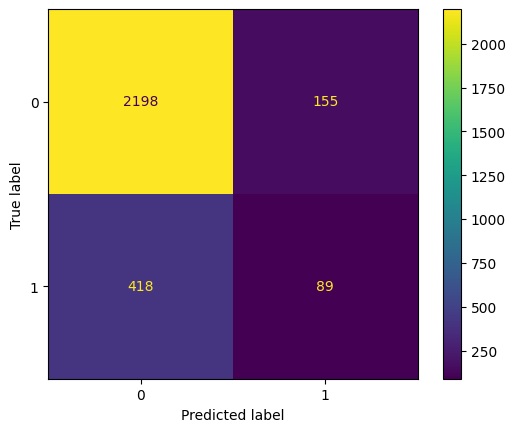

In [50]:
# Generate confusion matrix
cm = confusion_matrix(y_test, xgb_test_preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## 16. Feature Importance

Feature importance provides insight into which variables contributed most to model predictions.

This is useful not only for model interpretation, but also for understanding which behavioral patterns may be associated with churn risk.

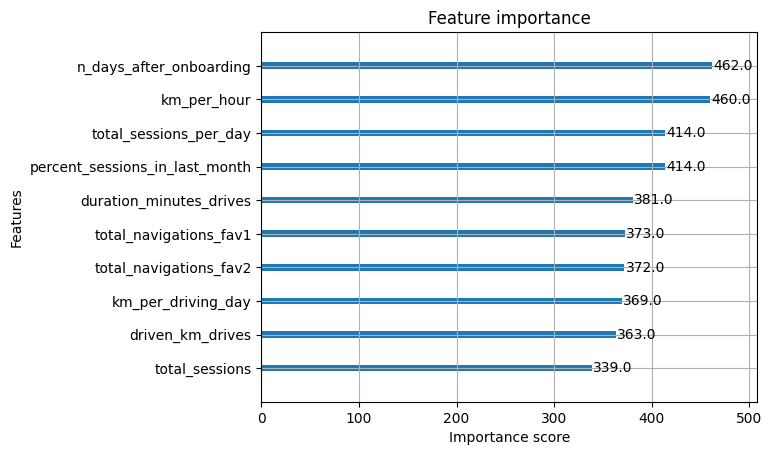

In [51]:
# Plot feature importance
plot_importance(xgb_cv.best_estimator_, max_num_features=10)
plt.show()

## 17. Conclusion

This project explored the use of machine learning models to predict user churn using behavioral usage data from Waze. Two ensemble tree-based models — **Random Forest** and **XGBoost** — were trained and evaluated using engineered features derived from user driving behavior and session activity.

The primary evaluation metric for this project was **recall**, because identifying users who are likely to churn is more important than avoiding false positives in this business context. Missing a user who is likely to churn represents a lost opportunity for retention interventions.

After training and tuning both models, their performance was compared using cross-validation and a validation dataset.

Key findings include:

- **Random Forest achieved higher precision and slightly higher overall accuracy.**
- **XGBoost achieved higher recall and a higher F1 score**, indicating stronger performance at identifying users who are likely to churn.
- Because recall was the primary metric, **XGBoost was selected as the champion model**.

Although the model's recall remains relatively modest, the results demonstrate that user behavioral features contain meaningful signals related to churn risk. The engineered features related to driving patterns, session frequency, and navigation behavior contributed to the model’s predictive capability.

Overall, this project demonstrates how machine learning can be applied to user activity data to support churn prediction. In a real-world deployment, this model would likely be used as a **decision-support tool** to help product teams identify users who may benefit from targeted retention strategies rather than as a fully automated decision system.

### Final Model Performance (Validation)

Champion Model: XGBoost

Recall: 0.181  
Precision: 0.382  
F1 Score: 0.246  
Accuracy: 0.803

## Bonus: Decision Threshold Optimization

Most classification models use a **default decision threshold of 0.5**.  
This means that if the model predicts a probability of **50% or greater** that a user will churn, the model assigns a prediction of **1 (churn)**.

However, when working with **imbalanced datasets**, this threshold is often not ideal. In this project, churned users represent a minority class, so using a strict 0.5 threshold may cause the model to miss many users who are actually likely to churn.

Because the primary goal of this project is to **identify as many potential churners as possible**, adjusting the decision threshold can significantly improve model usefulness.

---

## Precision–Recall Tradeoff

A **precision-recall curve** helps visualize the tradeoff between:

- **Precision** – how often predicted churners actually churn
- **Recall** – how many actual churners the model successfully identifies

As recall increases, precision typically decreases.

In the context of this business problem, false positives are relatively low-risk. If a user is incorrectly predicted to churn, the consequence might simply be receiving a retention email or notification. Therefore, improving **recall** can be beneficial even if precision decreases slightly.

---

## Adjusting the Decision Threshold

Instead of using the default threshold of **0.5**, we can generate predictions using a lower threshold.

First, obtain the predicted churn probabilities from the model:

```python
predicted_probabilities = xgb_cv.best_estimator_.predict_proba(X_test)

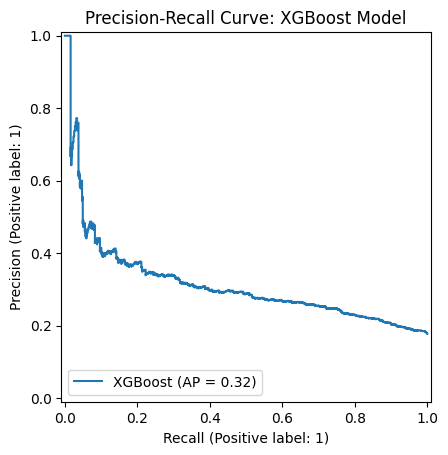

In [52]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Plot precision-recall curve
display = PrecisionRecallDisplay.from_estimator(
    xgb_cv.best_estimator_,
    X_test,
    y_test,
    name="XGBoost"
)

plt.title("Precision-Recall Curve: XGBoost Model")
plt.show()

## Adjusting the Decision Threshold

Instead of using the default threshold of **0.5**, predictions can be generated using a lower threshold.

First, obtain the predicted churn probabilities from the model.

In [53]:
# Get predicted probabilities from the champion model
predicted_probabilities = xgb_cv.best_estimator_.predict_proba(X_test)

predicted_probabilities[:10]

array([[0.9599097 , 0.04009031],
       [0.68676764, 0.31323236],
       [0.9879488 , 0.0120512 ],
       [0.9726365 , 0.0273635 ],
       [0.9815548 , 0.01844519],
       [0.7451408 , 0.25485924],
       [0.9878601 , 0.0121399 ],
       [0.9912229 , 0.00877706],
       [0.94201344, 0.05798655],
       [0.97871333, 0.02128669]], dtype=float32)

The `predict_proba()` function returns two probabilities for each user:


[ probability_not_churn , probability_churn ]

To adjust the threshold, we isolate the probability of churn and convert those probabilities into predictions using a new threshold.

Example: using a threshold of **0.4**

In [54]:
# Extract probability of churn
probs = [x[1] for x in predicted_probabilities]

# Apply new threshold
new_preds = np.array([1 if x >= 0.4 else 0 for x in probs])

new_preds[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [55]:
# Evaluate model with new threshold
get_test_scores("XGBoost (threshold = 0.4)", new_preds, y_test)

,model,precision,recall,F1,accuracy
0,XGBoost (threshold = 0.4),0.347953,0.234714,0.28033,0.786364


Lowering the threshold increased **recall**, meaning the model identified more users who are likely to churn. This comes with a small decrease in precision and accuracy, which is expected when prioritizing recall.

## Finding an Optimal Threshold

To systematically identify a threshold that achieves a desired recall level, we can evaluate many potential thresholds and select the one that produces a recall closest to our target.

In [56]:
def threshold_finder(y_test_data, probabilities, desired_recall):

    probs = [x[1] for x in probabilities]
    thresholds = np.arange(0, 1, 0.001)

    scores = []

    for threshold in thresholds:
        preds = np.array([1 if x >= threshold else 0 for x in probs])
        recall = recall_score(y_test_data, preds)
        scores.append((threshold, recall))

    distances = []

    for idx, score in enumerate(scores):
        distance = abs(score[1] - desired_recall)
        distances.append((idx, distance))

    sorted_distances = sorted(distances, key=lambda x: x[1])

    best_idx = sorted_distances[0][0]

    threshold, recall = scores[best_idx]

    return threshold, recall

In [57]:
# Get predicted probabilities
probabilities = xgb_cv.best_estimator_.predict_proba(X_test)

# Find threshold closest to recall of 0.5
threshold_finder(y_test, probabilities, 0.5)

(np.float64(0.14400000000000002), 0.5009861932938856)

The function identifies a decision threshold that produces a recall close to **0.5**, meaning the model successfully identifies roughly half of the users who actually churn.

In [58]:
# Apply optimal threshold
probs = [x[1] for x in probabilities]

new_preds = np.array([1 if x >= 0.194 else 0 for x in probs])

get_test_scores("XGBoost (threshold = 0.194)", new_preds, y_test)

,model,precision,recall,F1,accuracy
0,XGBoost (threshold = 0.194),0.294944,0.414201,0.344545,0.720629


## Key Takeaway

Adjusting the decision threshold is a powerful technique for tailoring a machine learning model to business objectives.

For churn prediction, increasing recall allows the model to identify more users who may leave the platform, enabling earlier retention interventions.

Rather than relying solely on the default threshold, tuning the decision boundary based on business priorities can significantly improve the practical value of a predictive model.

In [59]:
import pickle

# Save the trained XGBoost model
with open("xgb_churn_model.pkl", "wb") as file:
    pickle.dump(xgb_cv.best_estimator_, file)